# Notebook 3: Path Signature Theory & Feature Sandbox

Before feeding financial data into our Neural SDE, we must translate chaotic, noisy time series into clear geometric signals. We do this using the **Path Signature**.

### What is a Path Signature?
Imagine a time series not as a sequence of discrete prices, but as a continuous physical path moving through space. The Signature is a mathematical tool that extracts the "shape" of that path using an infinite series of iterated integrals. 

If we have a path $X_t$, the Signature $S(X)$ is a collection of numbers describing its trajectory.
* **Depth 1 (Increments):** Measures the absolute distance traveled from start to finish.
    $$S(X)^i = \int_{0}^{T} dX_t^i$$
* **Depth 2 (Areas):** Measures the "Lead-Lag" relationship. If we plot Asset A on the x-axis and Asset B on the y-axis, this integral calculates the signed area swept by the curve.
    $$S(X)^{i,j} = \int_{0}^{T} \int_{0}^{t} dX_s^i dX_t^j$$

### Classical Approach vs. Path Signatures
Why not just use traditional quantitative features?

| Feature | Classical Approach | Path Signature Approach |
| :--- | :--- | :--- |
| **Momentum** | Moving Averages (requires guessing the correct lookback window). | Depth 1 perfectly captures net trajectory regardless of time scaling. |
| **Correlation** | Pearson Correlation (only captures linear relationships, fails on delayed reactions). | Depth 2 explicitly captures non-linear lead-lag (who moved first). |
| **Volatility** | Rolling Standard Deviation (loses the sequence of events; an up-down shock looks the same as a down-up shock). | Higher depths explicitly encode the exact sequence and convexity of the shock. |
| **Dimensionality** | Adding explicit lags (e.g., $t-1, t-2, t-3$) causes the curse of dimensionality. | Compresses the entire path's history into a fixed-size, mathematically complete vector. |

In [2]:
import numpy as np
import pandas as pd
import esig
# import matplotlib.subplots as plt
import matplotlib.pyplot as plt

import seaborn as sns

def extract_signatures(data_array, window_size, signature_depth):
    """
    Slices a 2D array into rolling windows and extracts the Path Signature.
    """
    signatures = []
    for i in range(len(data_array) - window_size):
        window = data_array[i : i + window_size]
        # Force strict C-contiguous memory for the esig C++ backend
        window_clean = np.ascontiguousarray(window, dtype=np.float64)
        sig = esig.stream2sig(window_clean, signature_depth)
        signatures.append(sig)
        
    return np.array(signatures)

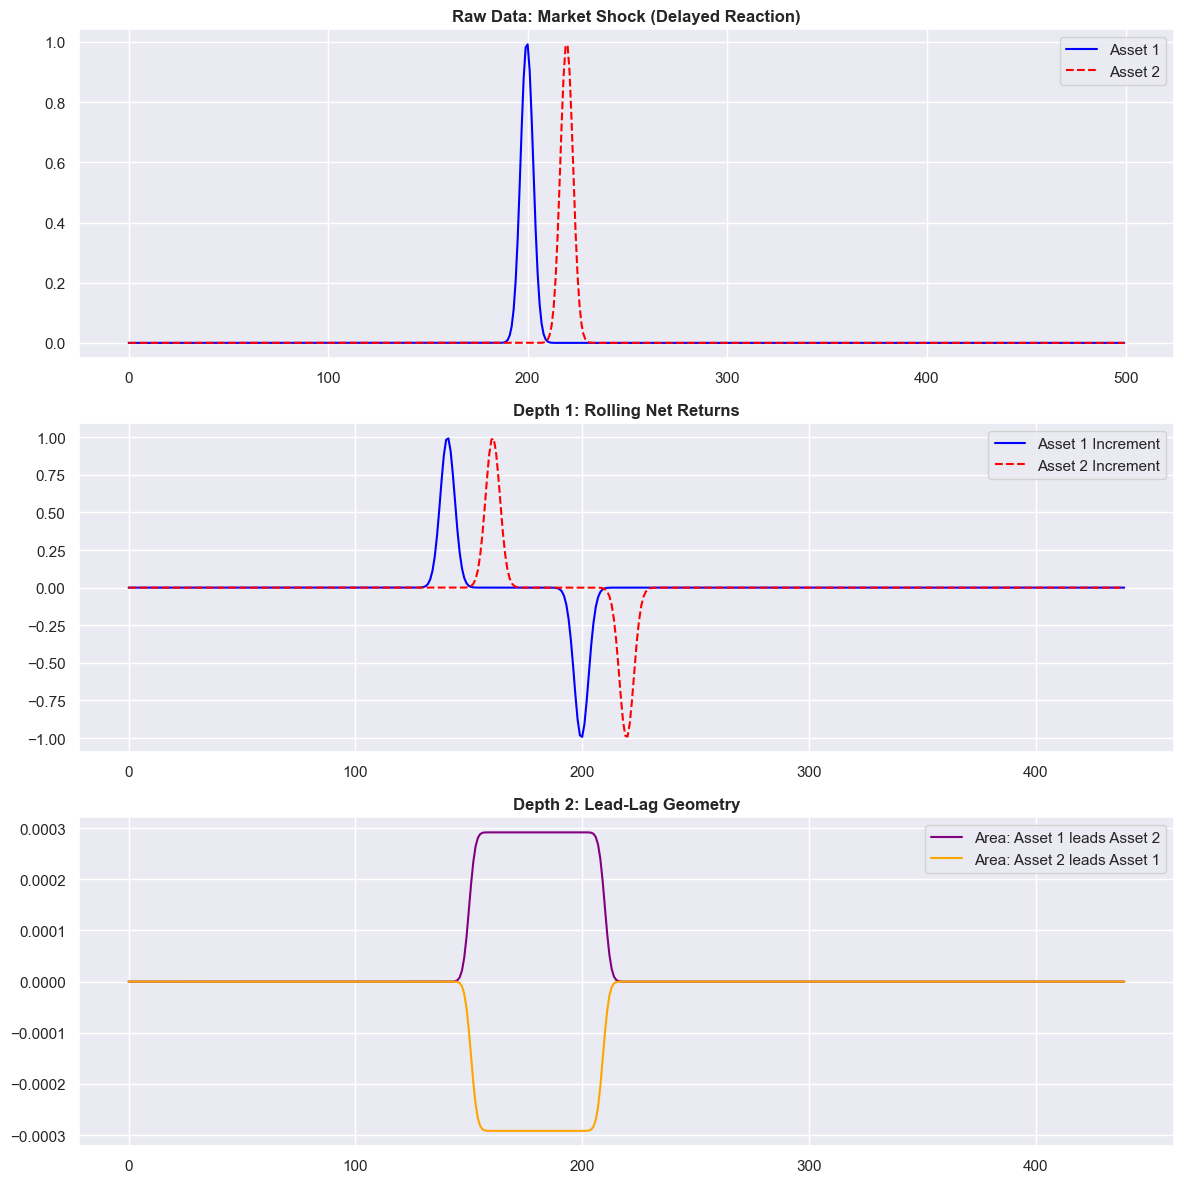

In [3]:
# Set up sandbox parameters
SCENARIO = "shock"  # Change this to "wave" or "shock" to test different market conditions
WINDOW_SIZE = 60
DEPTH = 2

# 1. GENERATE DATA BASED ON SCENARIO
if SCENARIO == "wave":
    t = np.linspace(0, 10 * np.pi, 500)
    asset1 = np.sin(t)
    asset2 = np.sin(t - np.pi/4)  # Asset 2 lags Asset 1
    title = "Smooth Market (Asset 1 Leads Asset 2)"
    
elif SCENARIO == "shock":
    t = np.linspace(0, 500, 500)
    asset1 = np.exp(-0.05 * (t - 200)**2)  # Catalyst spikes at 200
    asset2 = np.exp(-0.05 * (t - 220)**2)  # Reaction spikes at 220
    title = "Market Shock (Delayed Reaction)"

dummy_data = np.column_stack((asset1, asset2))

# 2. EXTRACT SIGNATURES
sig_matrix = extract_signatures(dummy_data, WINDOW_SIZE, DEPTH)

# 3. VISUALIZE
sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

# Raw Data
axes[0].plot(dummy_data[:, 0], label="Asset 1", color='blue')
axes[0].plot(dummy_data[:, 1], label="Asset 2", color='red', linestyle='--')
axes[0].set_title(f"Raw Data: {title}", fontweight='bold')
axes[0].legend()

# Depth 1: Increments
axes[1].plot(sig_matrix[:, 1], label="Asset 1 Increment", color='blue')
axes[1].plot(sig_matrix[:, 2], label="Asset 2 Increment", color='red', linestyle='--')
axes[1].set_title("Depth 1: Rolling Net Returns", fontweight='bold')
axes[1].legend()

# Depth 2: Lead-Lag
axes[2].plot(sig_matrix[:, 4], color="purple", label="Area: Asset 1 leads Asset 2")
axes[2].plot(sig_matrix[:, 5], color="orange", label="Area: Asset 2 leads Asset 1")
axes[2].set_title("Depth 2: Lead-Lag Geometry", fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.show()

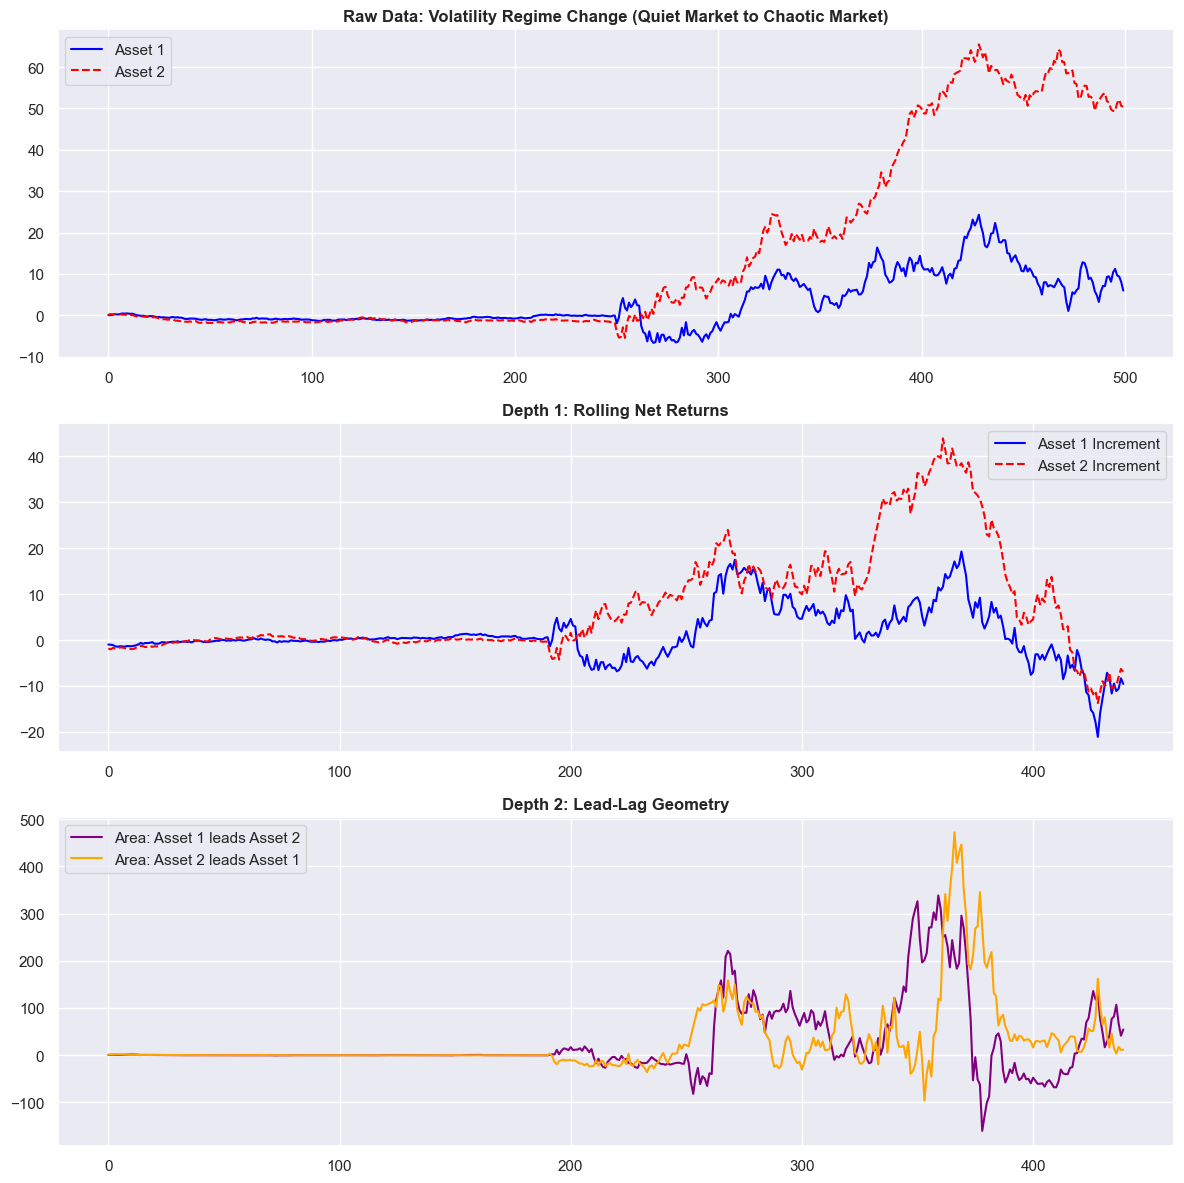

In [6]:
# Set up sandbox parameters
SCENARIO = "volatility_regime"  # Options: "wave", "shock", "mean_reversion"
WINDOW_SIZE = 60
DEPTH = 2

# ==========================================
# 1. GENERATE DATA BASED ON SCENARIO
# ==========================================
if SCENARIO == "wave":
    t = np.linspace(0, 10 * np.pi, 500)
    asset1 = np.sin(t)
    asset2 = np.sin(t - np.pi/4)
    title = "Smooth Market (Asset 1 Leads Asset 2)"
    
elif SCENARIO == "shock":
    t = np.linspace(0, 500, 500)
    asset1 = np.exp(-0.05 * (t - 200)**2)
    asset2 = np.exp(-0.05 * (t - 220)**2)
    title = "Market Shock (Delayed Reaction)"
    
elif SCENARIO == "mean_reversion":
    t = np.linspace(0, 500, 500)
    # Both assets follow a slow, general market wave
    baseline_trend = np.sin(t / 40) 
    
    # Asset 1 perfectly follows the market
    asset1 = baseline_trend
    
    # The Spread: Asset 2 diverges from Asset 1 around day 250, then reverts
    spread = 0.8 * np.exp(-0.005 * (t - 250)**2)
    asset2 = baseline_trend + spread
    
    title = "Mean Reversion (The Spread Opens and Closes)"

elif SCENARIO == "volatility_regime":
        # Lock the random seed so the chaotic data looks the same every time you run it
        np.random.seed(42) 
        t = np.linspace(0, 500, 500)
        
        # Volatility is low (0.1) for the first 250 days, then explodes to high (1.5)
        vol_multiplier = np.where(t < 250, 0.1, 1.5)
        
        # We simulate a Random Walk (the cumulative sum of daily returns)
        asset1 = np.cumsum(np.random.normal(0, vol_multiplier))
        
        # Asset 2 is correlated to Asset 1, but has its own independent noise
        asset2 = asset1 * 0.5 + np.cumsum(np.random.normal(0, vol_multiplier))
        
        title = "Volatility Regime Change (Quiet Market to Chaotic Market)"
dummy_data = np.column_stack((asset1, asset2))

# ==========================================
# 2. EXTRACT SIGNATURES (No changes needed here)
# ==========================================
sig_matrix = extract_signatures(dummy_data, WINDOW_SIZE, DEPTH)

# ==========================================
# 3. VISUALIZE (No changes needed here)
# ==========================================
sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

# Raw Data
axes[0].plot(dummy_data[:, 0], label="Asset 1", color='blue')
axes[0].plot(dummy_data[:, 1], label="Asset 2", color='red', linestyle='--')
axes[0].set_title(f"Raw Data: {title}", fontweight='bold')
axes[0].legend()

# Depth 1: Increments
axes[1].plot(sig_matrix[:, 1], label="Asset 1 Increment", color='blue')
axes[1].plot(sig_matrix[:, 2], label="Asset 2 Increment", color='red', linestyle='--')
axes[1].set_title("Depth 1: Rolling Net Returns", fontweight='bold')
axes[1].legend()

# Depth 2: Lead-Lag
axes[2].plot(sig_matrix[:, 4], color="purple", label="Area: Asset 1 leads Asset 2")
axes[2].plot(sig_matrix[:, 5], color="orange", label="Area: Asset 2 leads Asset 1")
axes[2].set_title("Depth 2: Lead-Lag Geometry", fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.show()

--- CLASSICAL STATISTICS ---
Path A - Net Return: -1.0000 | Volatility: 0.0685
Path B - Net Return: 1.0000 | Volatility: 0.0685
Notice how similar they look to a classical model!

--- PATH SIGNATURE (Depth 2 Area) ---
Path A - Shape Signature: -0.1009
Path B - Shape Signature: 0.8990
The Signature completely separates them with opposing mathematical signs!


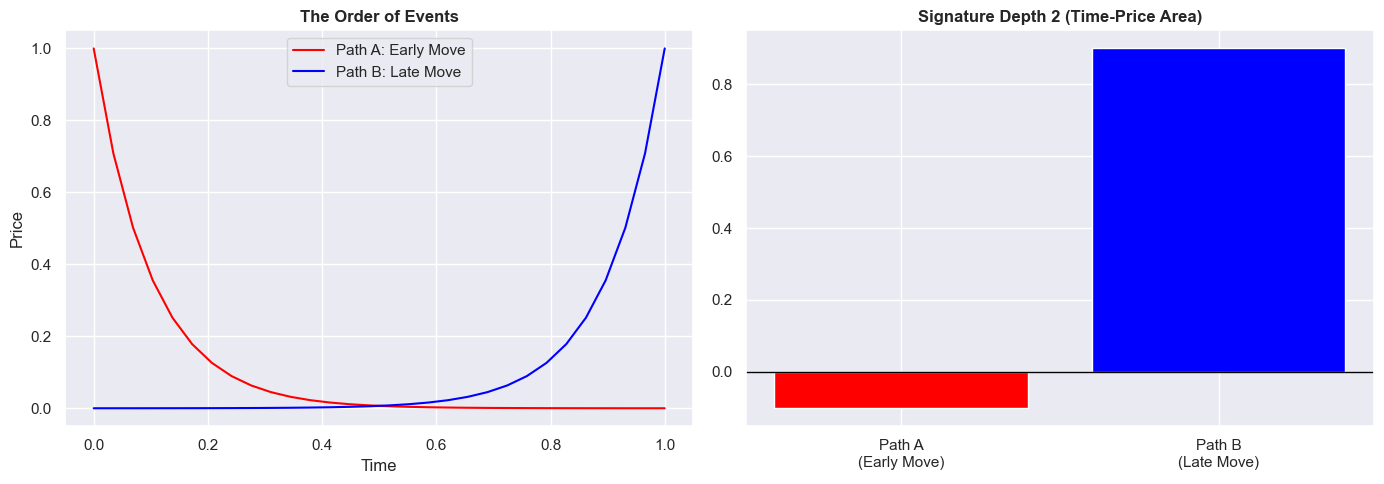

In [7]:
import numpy as np
import pandas as pd
import esig
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. GENERATE THE "ORDER OF EVENTS" SCENARIOS
# ==========================================
t = np.linspace(0, 1, 30)  # A 30-day window

# Scenario A: Shoots up early, slowly bleeds down
price_A = np.exp(-10 * t) 

# Scenario B: Bleeds down slowly, shoots up late
price_B = np.exp(-10 * (1 - t))

# TIME AUGMENTATION: We must pair the price with time to get 2D geometry
path_A = np.column_stack((t, price_A))
path_B = np.column_stack((t, price_B))

# ==========================================
# 2. CLASSICAL STATS VS SIGNATURES
# ==========================================
# Classical Stats
ret_A = price_A[-1] - price_A[0]
ret_B = price_B[-1] - price_B[0]
vol_A = np.std(np.diff(price_A))
vol_B = np.std(np.diff(price_B))

# Signature Extraction (Depth 2)
sig_A = esig.stream2sig(path_A, 2)
sig_B = esig.stream2sig(path_B, 2)

print("--- CLASSICAL STATISTICS ---")
print(f"Path A - Net Return: {ret_A:.4f} | Volatility: {vol_A:.4f}")
print(f"Path B - Net Return: {ret_B:.4f} | Volatility: {vol_B:.4f}")
print("Notice how similar they look to a classical model!\n")

print("--- PATH SIGNATURE (Depth 2 Area) ---")
# Index 4 is the area swept by Time -> Price
print(f"Path A - Shape Signature: {sig_A[4]:.4f}")
print(f"Path B - Shape Signature: {sig_B[4]:.4f}")
print("The Signature completely separates them with opposing mathematical signs!")

# ==========================================
# 3. VISUALIZATION
# ==========================================
sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(t, price_A, color='red', label="Path A: Early Move")
axes[0].plot(t, price_B, color='blue', label="Path B: Late Move")
axes[0].set_title("The Order of Events", fontweight='bold')
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Price")
axes[0].legend()

# Visualizing the difference in Signature
axes[1].bar(['Path A\n(Early Move)', 'Path B\n(Late Move)'], [sig_A[4], sig_B[4]], color=['red', 'blue'])
axes[1].set_title("Signature Depth 2 (Time-Price Area)", fontweight='bold')
axes[1].axhline(0, color='black', linewidth=1)

plt.tight_layout()
plt.show()

In [28]:
def visualization_sgn(price_path, daily_returns, results, sig_matrix):
    # ==========================================
    # 3. VISUALIZATION
    # ==========================================
    sns.set_theme(style="darkgrid")
    fig, axes = plt.subplots(3, 2, figsize=(12, 12))

    # PLOT 1: The Raw Random Walk
    axes[0][0].plot(price_path, color='black')
    axes[0][0].set_title(f"Raw Data: Random Walk (μ={mu}, σ={sigma})", fontweight='bold')
    axes[0][0].set_ylabel("Price")

    # PLOT 2: The Raw Random Walk
    axes[0][1].plot(daily_returns, color='black')
    axes[0][1].set_title(f"Raw Data: Random Walk (μ={mu}, σ={sigma})", fontweight='bold')
    axes[0][1].set_ylabel("Returns")

    # PLOT 2: Depth 1 (Rolling Net Return)
    # Index 2 is the Price increment (since Index 1 is the Time increment)
    axes[1][0].plot(sig_matrix[:, 2], color='blue', alpha=0.7)
    axes[1][0].axhline(mu * window_size, color='red', linestyle='--', label="Expected Drift")
    axes[1][0].set_title("Depth 1: Rolling Window Net Returns", fontweight='bold')
    axes[1][0].set_ylabel("Net Return")
    axes[1][0].legend()

    # PLOT 3: Depth 2 (Time-Price Area)
    # Index 4 is the area swept by Time -> Price
    axes[1][1].plot(sig_matrix[:, 4], color='purple', alpha=0.7)
    axes[1][1].axhline(0, color='black', linewidth=1)
    axes[1][1].set_title("Depth 2: Rolling Trajectory Shape (Time-Price Area)", fontweight='bold')
    axes[1][1].set_ylabel("Geometric Area")

    # PLOT 2: Depth 1 (Rolling Net Return)
    # Index 2 is the Price increment (since Index 1 is the Time increment)
    axes[2][0].plot(results['mean'], color='blue', alpha=0.7)
    # axes[2][0].axhline(mu * window_size, color='red', linestyle='--', label="Expected Drift")
    axes[2][0].set_title("Depth 1: Rolling Window Net Returns", fontweight='bold')
    axes[2][0].set_ylabel("Net Return")
    axes[2][0].legend()

    # PLOT 3: Depth 2 (Time-Price Area)
    # Index 4 is the area swept by Time -> Price
    axes[2][1].plot(results['std'], color='purple', alpha=0.7)
    # axes[2][1].axhline(0, color='black', linewidth=1)
    axes[2][1].set_title("Depth 2: Rolling Trajectory Shape (Time-Price Area)", fontweight='bold')
    axes[2][1].set_ylabel("Geometric Area")

    plt.tight_layout()
    plt.show()

C:\Users\fe_ma\AppData\Local\Temp\ipykernel_23200\1240230919.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2][0].legend()


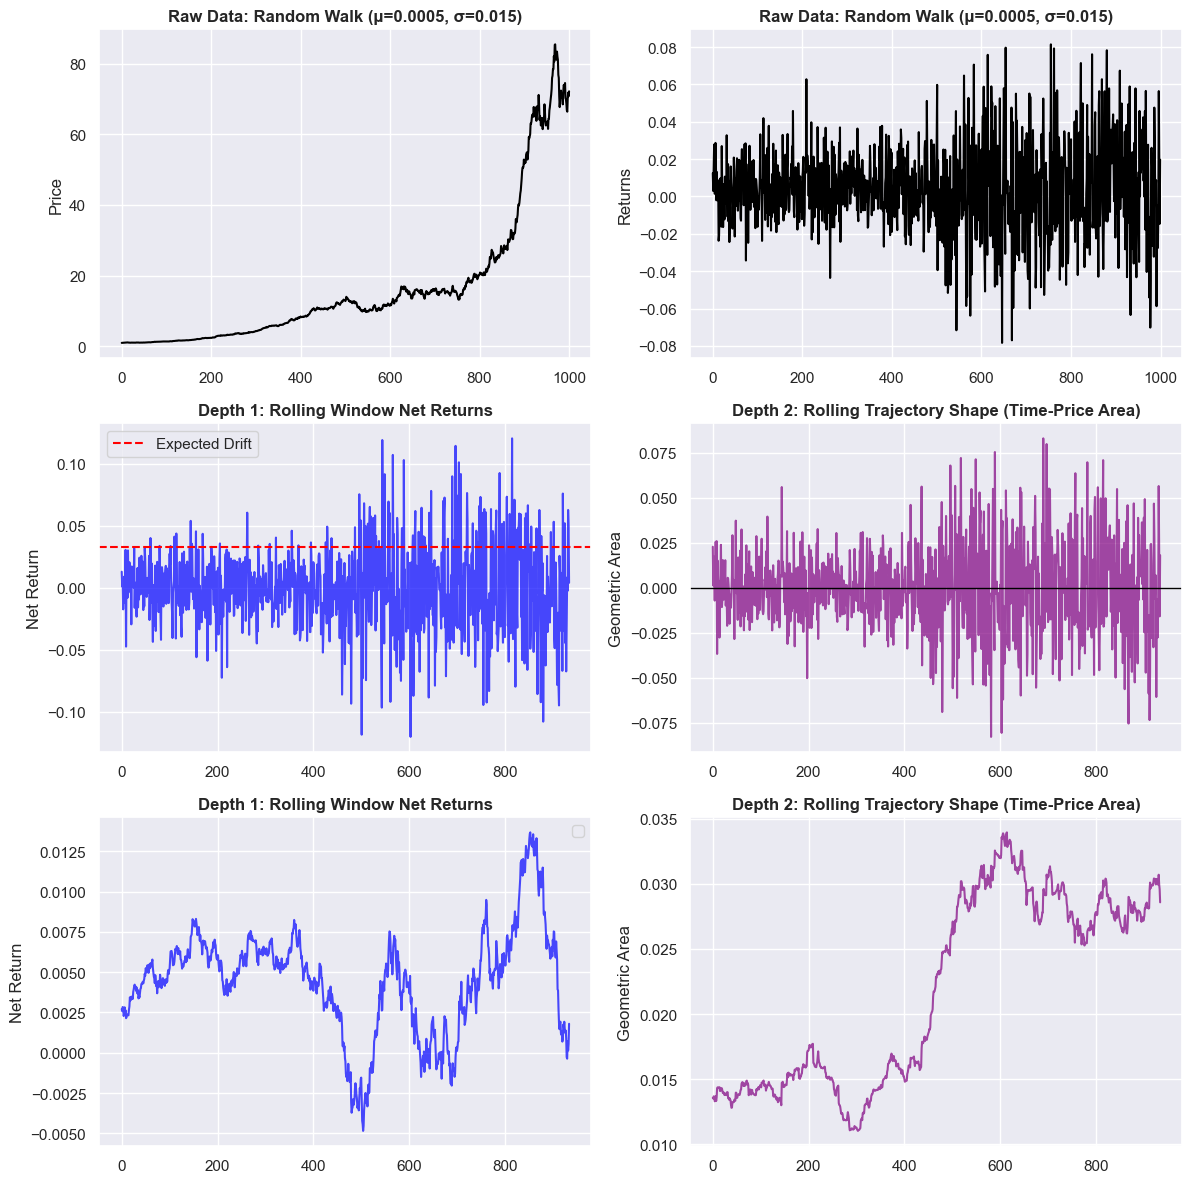

In [37]:
import numpy as np
import esig
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. GENERATE A REALISTIC RANDOM WALK
# ==========================================
np.random.seed(42)  # Lock seed for reproducibility
n_days = 1000

# Constants for our Normal Distribution
mu_1 = 0.005     # Slight positive daily drift
mu_2 = mu_1 / 2     # Slight positive daily drift

sigma_1 = 0.015   # Constant daily volatility (approx 1.5%)
sigma_2 = sigma_1 * 2   # Constant daily volatility (approx 1.5%)

# Generate daily returns from a Normal Distribution
daily_returns_1 = np.random.normal(mu_1, sigma_1, int(n_days / 2))
daily_returns_2 = np.random.normal(mu_2, sigma_2, int(n_days / 2))

# (daily_returns_1 + daily_returns_2).shape
daily_returns = np.concatenate([daily_returns_1, daily_returns_2])

# Create the price path (Cumulative Sum of returns)
# price_path = np.exp(np.cumsum(daily_returns))
price_path = np.exp(np.cumsum(np.insert(daily_returns, 0, 0)))
# ==========================================
# 2. EXTRACT SIGNATURES WITH A ROLLING WINDOW
# ==========================================
window_size = 3 * 22
depth = 2
signatures = []

# mean_results = []
# std_results = []
results = {'mean': [], 'std': []}

# We create a "local" time axis for the window (e.g., normalized from 0 to 1)
# This ensures the Signature measures the shape exactly the same way every time
local_time = np.linspace(0, 1, window_size)

for i in range(len(price_path) - window_size):
    # window_price = price_path[i : i + window_size]
    window_price = daily_returns[i : i + window_size]
    mean_avg = np.mean(window_price)
    std_avg = np.std(window_price)
    results['mean'].append(mean_avg)
    results['std'].append(std_avg)

    # TIME AUGMENTATION: Pair local time with the window's price
    window_2d = np.column_stack((local_time, window_price))
    
    # Clean memory for C++ engine
    window_clean = np.ascontiguousarray(window_2d, dtype=np.float64)
    sig = esig.stream2sig(window_clean, depth)
    signatures.append(sig)

sig_matrix = np.array(signatures)

visualization_sgn(price_path, daily_returns, results, sig_matrix)



Extracting Signatures for Dataset 1...
Extracting Signatures for Dataset 2...
Training Model 1 (Constant Volatility)...
Training Model 2 (Volatility Spike)...


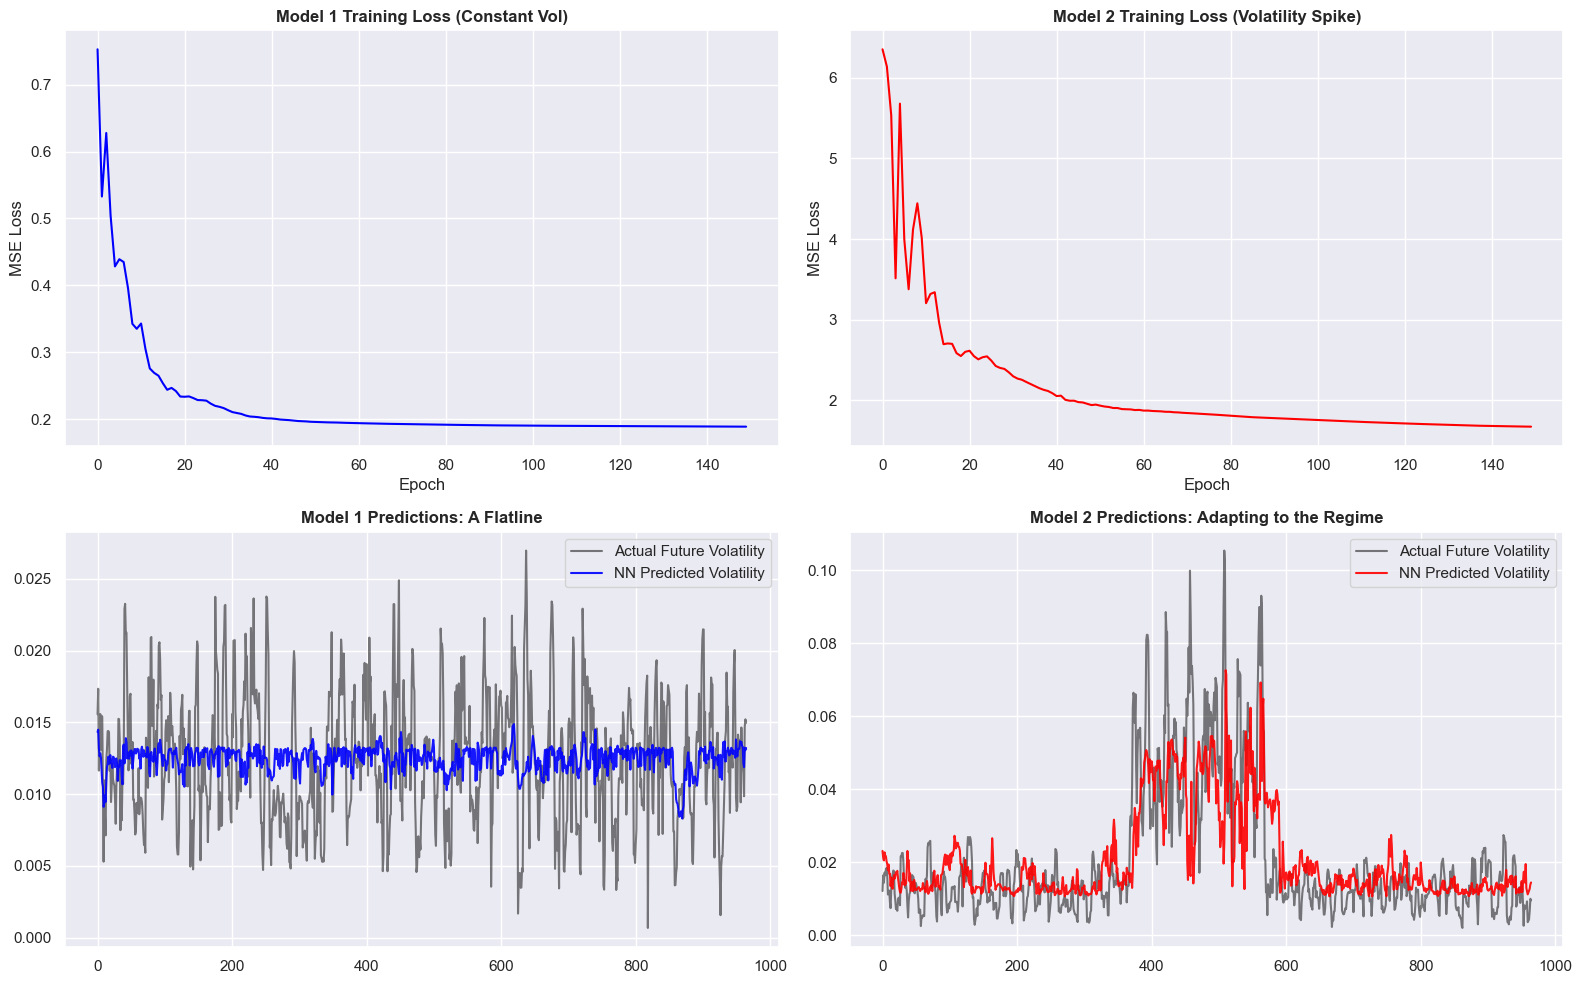

In [42]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import esig
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. GENERATE SYNTHETIC DATA
# ==========================================
np.random.seed(42)
n_days = 1000
window_size = 30
forward_window = 5

# Dataset 1: Perfect Random Walk (Constant Vol)
constant_vol = 0.015 * 100
returns_1 = np.random.normal(0, constant_vol, n_days)
price_1 = np.cumsum(returns_1)

# Dataset 2: Volatility Regime Change
# Vol is 0.015, but spikes to 0.06 between day 400 and 600
vol_path = np.where((np.arange(n_days) > 400) & (np.arange(n_days) < 600), 0.06, 0.015) * 100
returns_2 = np.random.normal(0, vol_path)
price_2 = np.cumsum(returns_2)

# ==========================================
# 2. EXTRACT SIGNATURES & TARGETS
# ==========================================
def prepare_dataset(price_path, returns_path):
    X_sigs = []
    y_target_vol = []
    
    local_time = np.linspace(0, 1, window_size)
    
    # Slide through the data
    for i in range(len(price_path) - window_size - forward_window):
        # The Window
        window_price = price_path[i : i + window_size]
        window_2d = np.column_stack((local_time, window_price))
        window_clean = np.ascontiguousarray(window_2d, dtype=np.float64)
        
        # Extract Signature (Depth 2)
        sig = esig.stream2sig(window_clean, 2)
        X_sigs.append(sig)
        
        # The Target: Actual Volatility of the NEXT 5 days
        future_returns = returns_path[i + window_size : i + window_size + forward_window]
        future_vol = np.std(future_returns)
        y_target_vol.append(future_vol)
        
    return torch.tensor(np.array(X_sigs), dtype=torch.float32), torch.tensor(np.array(y_target_vol), dtype=torch.float32).unsqueeze(1)

print("Extracting Signatures for Dataset 1...")
X1, y1 = prepare_dataset(price_1, returns_1)

print("Extracting Signatures for Dataset 2...")
X2, y2 = prepare_dataset(price_2, returns_2)

# ==========================================
# 3. DEFINE THE NEURAL NETWORK (Diffusion Estimator)
# ==========================================
class NeuralDiffusionSDE(nn.Module):
    def __init__(self, input_dim):
        super(NeuralDiffusionSDE, self).__init__()
        # A simple Feed-Forward Network
        self.net = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
            nn.Softplus() # Volatility must be positive!
        )
        
    def forward(self, x):
        return self.net(x)

# ==========================================
# 4. TRAINING LOOP
# ==========================================
def train_model(X, y, epochs=150):
    model = NeuralDiffusionSDE(input_dim=X.shape[1])
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.005)
    
    losses = []
    for epoch in range(epochs):
        optimizer.zero_grad()
        predictions = model(X)
        loss = criterion(predictions, y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        
    # Get final predictions for plotting
    with torch.no_grad():
        final_preds = model(X).numpy()
        
    return losses, final_preds

print("Training Model 1 (Constant Volatility)...")
loss1, preds1 = train_model(X1, y1)

print("Training Model 2 (Volatility Spike)...")
loss2, preds2 = train_model(X2, y2)

# ==========================================
# 5. VISUALIZE THE RESULTS
# ==========================================
sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# -- Model 1: Constant Volatility --
axes[0, 0].plot(loss1, color='blue')
axes[0, 0].set_title("Model 1 Training Loss (Constant Vol)", fontweight='bold')
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("MSE Loss")

axes[1, 0].plot(y1.numpy() / 100, label="Actual Future Volatility", color='black', alpha=0.5)
axes[1, 0].plot(preds1 / 100, label="NN Predicted Volatility", color='blue', alpha=0.9)
axes[1, 0].set_title("Model 1 Predictions: A Flatline", fontweight='bold')
axes[1, 0].legend()

# -- Model 2: Volatility Spike --
axes[0, 1].plot(loss2, color='red')
axes[0, 1].set_title("Model 2 Training Loss (Volatility Spike)", fontweight='bold')
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("MSE Loss")

axes[1, 1].plot(y2.numpy() / 100, label="Actual Future Volatility", color='black', alpha=0.5)
axes[1, 1].plot(preds2 / 100, label="NN Predicted Volatility", color='red', alpha=0.9)
axes[1, 1].set_title("Model 2 Predictions: Adapting to the Regime", fontweight='bold')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

Starting PIT Backtest: Total Samples = 965, Initial Train = 300
Processed up to index 320 / 965
Processed up to index 340 / 965
Processed up to index 360 / 965
Processed up to index 380 / 965
Processed up to index 400 / 965
Processed up to index 420 / 965
Processed up to index 440 / 965
Processed up to index 460 / 965
Processed up to index 480 / 965
Processed up to index 500 / 965
Processed up to index 520 / 965
Processed up to index 540 / 965
Processed up to index 560 / 965
Processed up to index 580 / 965
Processed up to index 600 / 965
Processed up to index 620 / 965
Processed up to index 640 / 965
Processed up to index 660 / 965
Processed up to index 680 / 965
Processed up to index 700 / 965
Processed up to index 720 / 965
Processed up to index 740 / 965
Processed up to index 760 / 965
Processed up to index 780 / 965
Processed up to index 800 / 965
Processed up to index 820 / 965
Processed up to index 840 / 965
Processed up to index 860 / 965
Processed up to index 880 / 965
Processe

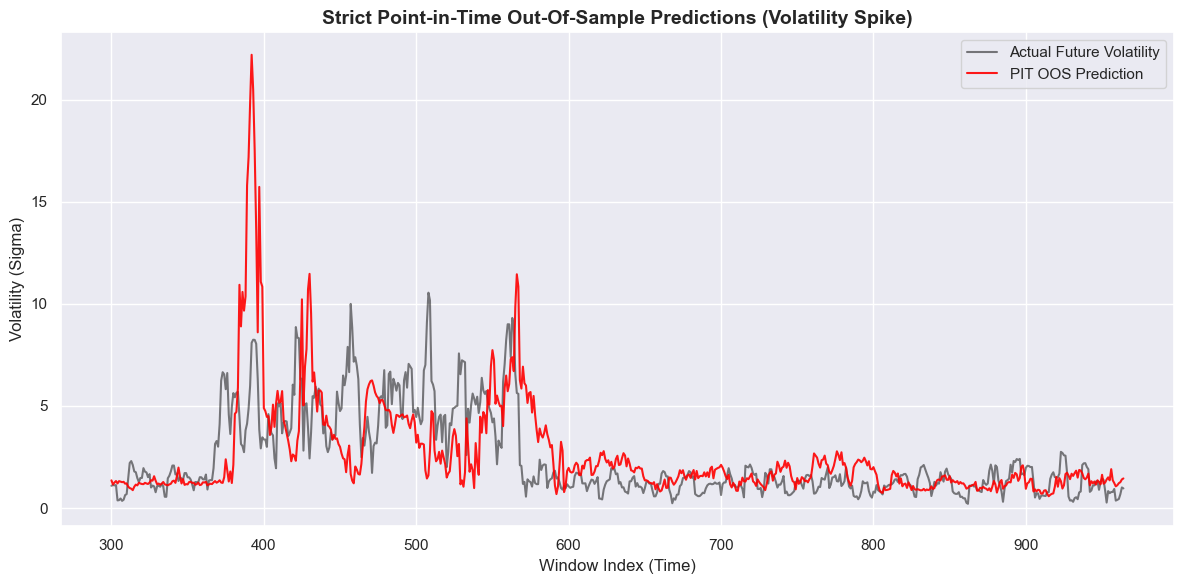

In [43]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from copy import deepcopy

# ==========================================
# 1. POINT-IN-TIME (PIT) BACKTESTER
# ==========================================
def pit_backtest(X, y, initial_train_size, step_size, epochs=200):
    """
    Executes a strict Point-in-Time walk-forward backtest.
    
    Args:
        X (torch.Tensor): Feature Matrix (Signatures).
        y (torch.Tensor): Target Matrix (Future Volatility).
        initial_train_size (int): Number of samples for the first training run.
        step_size (int): How many days to predict before retraining.
        epochs (int): Training epochs per walk-forward step.
        
    Returns:
        np.array: Strictly out-of-sample predictions.
    """
    total_samples = len(X)
    out_of_sample_preds = []
    out_of_sample_actuals = []
    
    print(f"Starting PIT Backtest: Total Samples = {total_samples}, Initial Train = {initial_train_size}")
    
    # The Walk-Forward Loop
    for current_t in range(initial_train_size, total_samples, step_size):
        # 1. Isolate strict historical data (NO FUTURE LEAKAGE)
        X_train = X[:current_t]
        y_train = y[:current_t]
        
        # 2. PIT Normalization: Scale targets to help the Neural Network (x100 for vol)
        # We only use training data to determine the scaling factor!
        scale_factor = 100.0 
        y_train_scaled = y_train * scale_factor
        
        # 3. Define the Out-Of-Sample (OOS) Test Window
        end_test = min(current_t + step_size, total_samples)
        X_test = X[current_t:end_test]
        y_test = y[current_t:end_test] # Stored only for our final charts
        
        # 4. Initialize and Train Model
        # (In a real scenario, you might 'warm start' from the previous model, 
        # but resetting ensures we don't carry over stale gradients)
        model = NeuralDiffusionSDE(input_dim=X_train.shape[1])
        optimizer = optim.Adam(model.parameters(), lr=0.005)
        criterion = nn.MSELoss()
        
        for epoch in range(epochs):
            optimizer.zero_grad()
            predictions = model(X_train)
            loss = criterion(predictions, y_train_scaled)
            loss.backward()
            optimizer.step()
            
        # 5. Out-of-Sample Prediction (Frozen Model)
        with torch.no_grad():
            oos_pred_scaled = model(X_test)
            # Un-scale the predictions back to real volatility terms
            oos_pred = oos_pred_scaled / scale_factor
            
            out_of_sample_preds.extend(oos_pred.numpy().flatten())
            out_of_sample_actuals.extend(y_test.numpy().flatten())
            
        print(f"Processed up to index {end_test} / {total_samples}")

    return np.array(out_of_sample_preds), np.array(out_of_sample_actuals)

# ==========================================
# 2. RUN THE BACKTEST ON SYNTHETIC DATA
# ==========================================
# We will test this on Dataset 2 (The Volatility Regime Change) from our previous cell
# Let's train on the first 300 days, then predict 20 days at a time
initial_train = 300
step = 20

oos_predictions, oos_actuals = pit_backtest(X2, y2, initial_train_size=initial_train, step_size=step, epochs=300)

# ==========================================
# 3. VISUALIZE STRICTLY OUT-OF-SAMPLE RESULTS
# ==========================================
sns.set_theme(style="darkgrid")
plt.figure(figsize=(12, 6))

# We need to offset our x-axis because we only have predictions AFTER the initial training window
time_axis = np.arange(initial_train, initial_train + len(oos_predictions))

plt.plot(time_axis, oos_actuals, label="Actual Future Volatility", color='black', alpha=0.5)
plt.plot(time_axis, oos_predictions, label="PIT OOS Prediction", color='red', alpha=0.9)

plt.title("Strict Point-in-Time Out-Of-Sample Predictions (Volatility Spike)", fontweight='bold', fontsize=14)
plt.xlabel("Window Index (Time)")
plt.ylabel("Volatility (Sigma)")
plt.legend()
plt.tight_layout()
plt.show()